<a href="https://colab.research.google.com/github/sangitaGIT011/Myproj/blob/main/Gold_Price_Prediction_Current26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2511 entries, 0 to 2510
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2511 non-null   object 
 1   Close          2511 non-null   float64
 2   High           2511 non-null   float64
 3   Low            2511 non-null   float64
 4   Open           2511 non-null   float64
 5   Volume         2511 non-null   int64  
 6   Adj Close      2511 non-null   float64
 7   Daily_Return   2510 non-null   float64
 8   MA_20          2492 non-null   float64
 9   MA_50          2462 non-null   float64
 10  MA_200         2312 non-null   float64
 11  Volatility_20  2491 non-null   float64
 12  Year           2511 non-null   int64  
 13  Month          2511 non-null   int64  
 14  Day_of_Week    2511 non-null   int64  
 15  Quarter        2511 non-null   int64  
dtypes: float64(10), int64(5), object(1)
memory usage: 314.0+ KB
         Date       Close        Hig

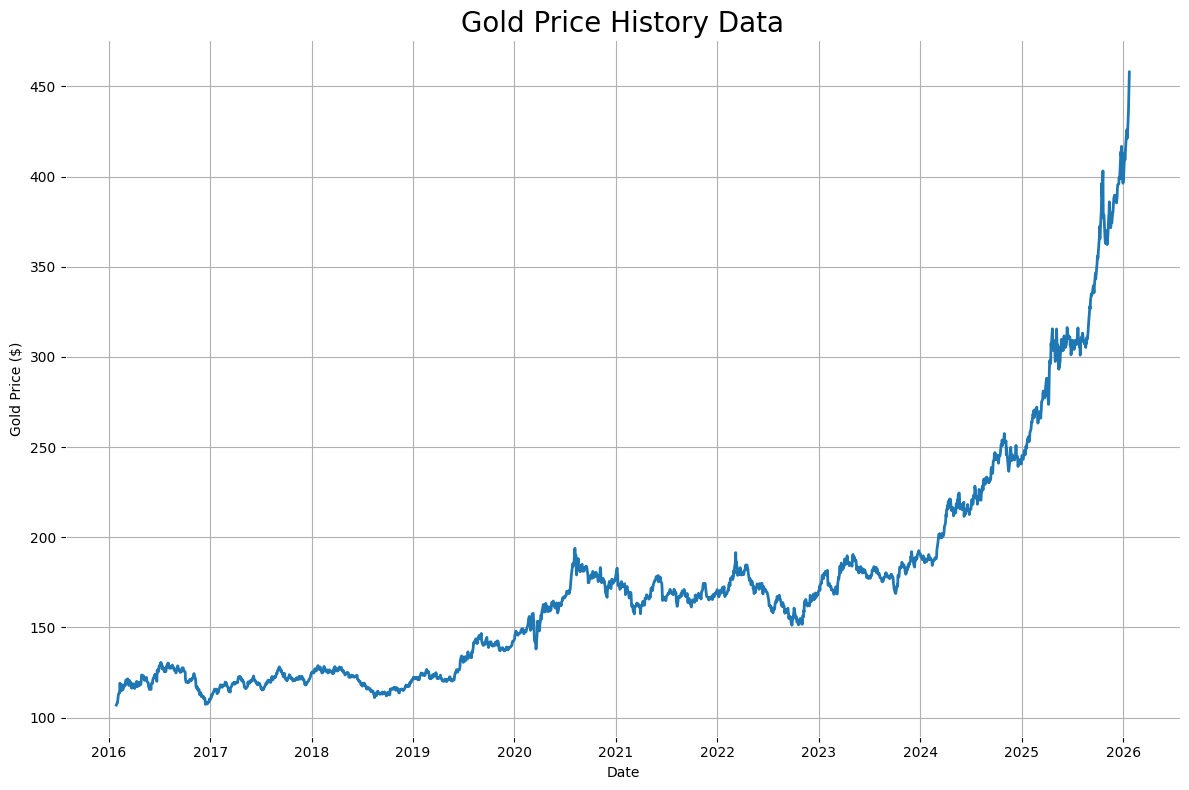

Isolate the 2022 temporal window and execute a contiguous time-series train-test split within that specific subset
Splitting Data to  Test Sets: 251


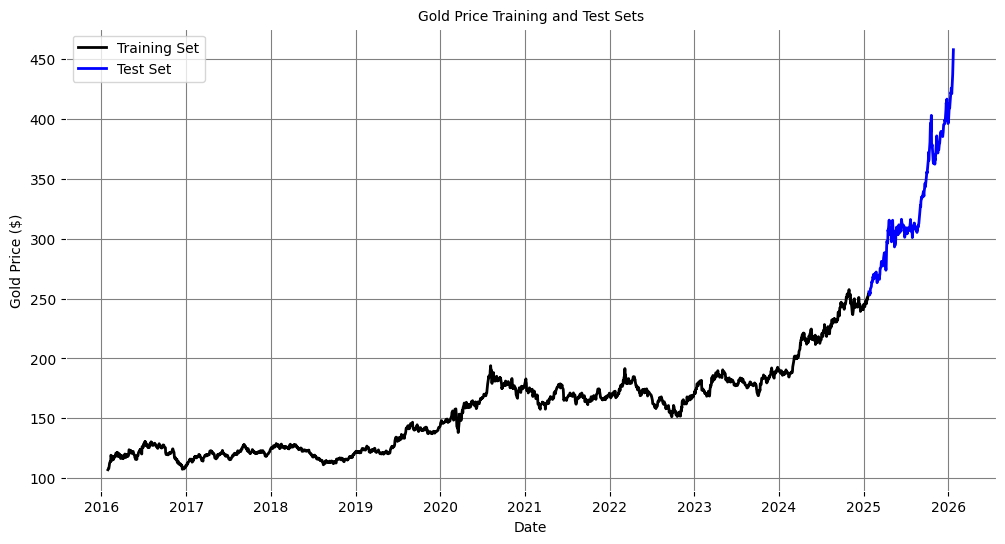

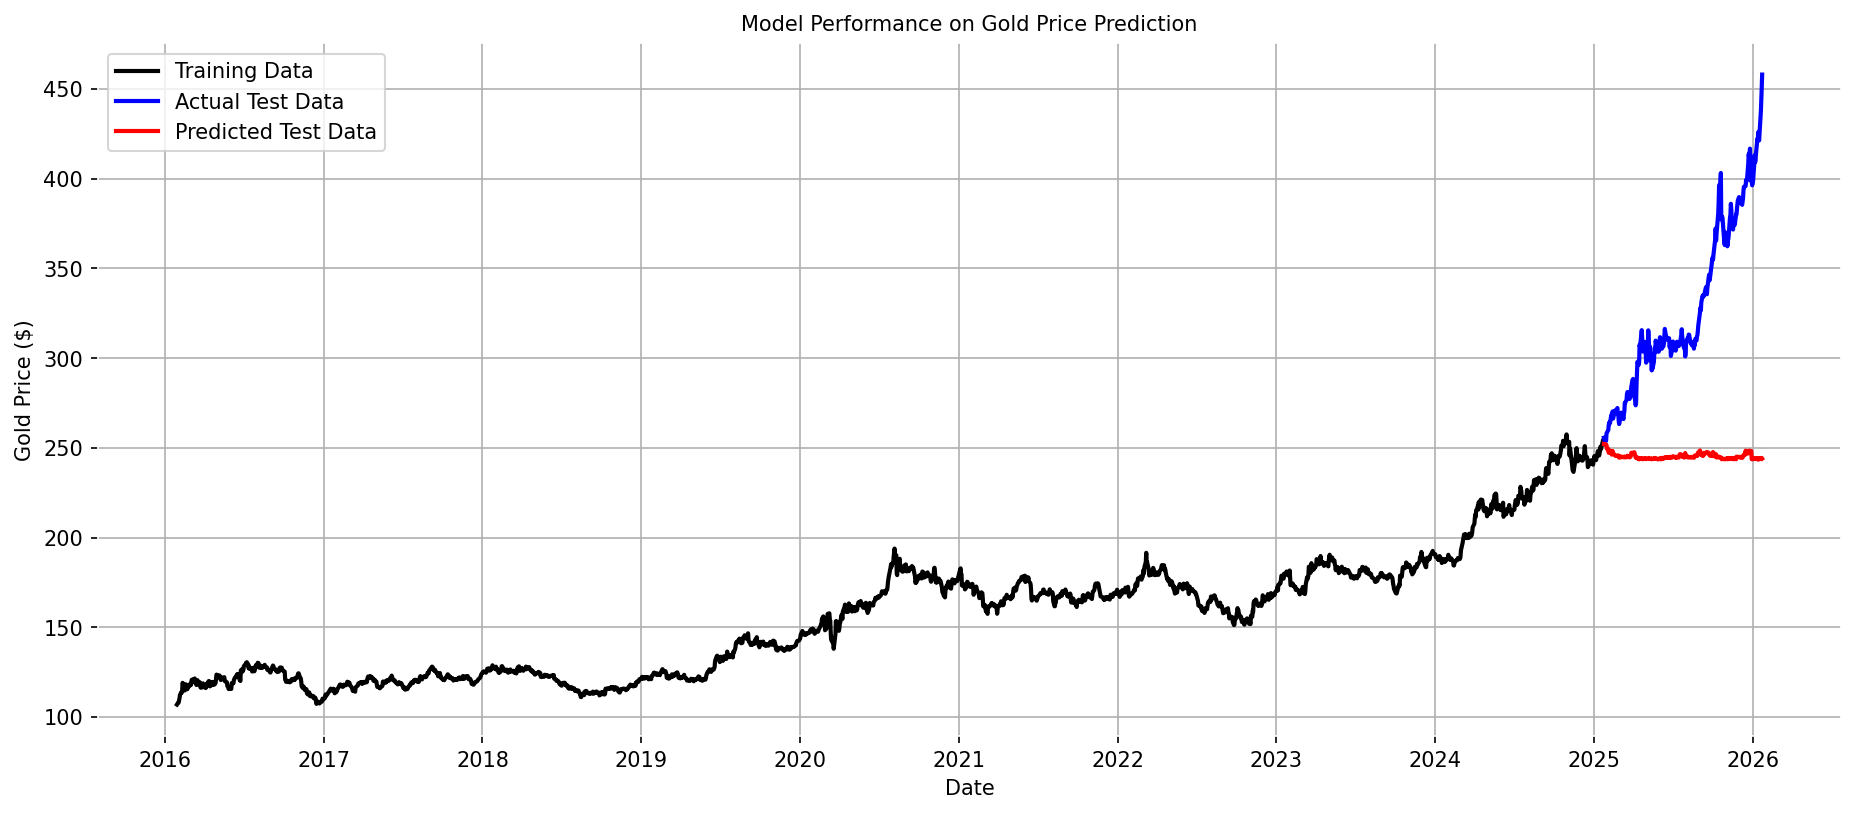

In [ ]:
from sklearn.utils.metadata_routing import process_routing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

'''import warnings
warnings.filterwarnings("ignore")

sns.set_style(
    "darkgrid",
    {"grid.color": ".6", "grid.linestyle": ":"}
)'''

# *********************************
#  DATASET LOADING of LAST 10Yrs From 2016 to 2026
# *********************************
df = pd.read_csv(
    "https://raw.githubusercontent.com/sangitaGIT011/Myproj/refs/heads/main/Gold_Price_2016to2026.csv"
)
df.info()
print(df.head())

print('Data PREPARATION')
# *********************************
# CLEAN COLUMN NAMES TRIMS AWAY ANY ACCIDENTAL
# *********************************
df.columns = df.columns.str.strip()
# *********************************
# CONVERT DATE COLUMN  INTO STANDARDIZED TIMESTAMPS.
# *********************************'''
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True,
    errors='coerce'
)
# *********************************
# DATA SORTING and INDEXING ON DATE
# *********************************
df = df.sort_values('Date')
#df.set_index('Date', inplace=True)

df.set_index('Date', inplace=True)
print("Date has been set as the row Index.")

# 2. Sort chronologically by the new index
df = df.sort_index(ascending=True)
print("Dataframe sorted   ascending order.")


# *********************************
print('Checking Duplicates Missing values')
# FILL MISSING VALUES
# *********************************
# 1. Fill the missing values AND save the results back to df
df = df.fillna(df.mean(numeric_only=True))

# 2. Print the total number of missing values remaining (Should be 0)
print("Total Missing Values:", df.isnull().sum().sum())

# 3. Print the total number of duplicate rows found
print("Total Duplicate Rows:", df.duplicated().sum())
# *********************************
# GOLD  HISTORICAL DATA
# *********************************

plt.figure(figsize=(12,8))

# PLOT GRAPH
plt.plot(
    df.index,
    df['Close'],
    linewidth=2
)
# TITLE & LABELS
plt.title("Gold Price History Data",fontsize=20)
plt.xlabel("Date")
plt.ylabel("Gold Price ($)")
plt.grid(True)
plt.tight_layout()
plt.show()


#Splitting Data to  Test Sets
print('===============')
print('Isolate the 2022 temporal window and execute a contiguous time-series train-test split within that specific subset')
test_size = df[df.index.year == 2022].shape[0]
print('Splitting Data to  Test Sets:',test_size)
print('===============')
# *********************************
# Splitting Data to Training & Test Sets
#TRAINING & TEST SET GRAPH
# ********************************
plt.figure(figsize=(12, 6), dpi=100)
plt.rc('axes', edgecolor='white')
# TRAINING DATA
plt.plot(

    df.index[:-test_size],
    df['Close'][:-test_size],
    color='black',
    lw=2
)
# TEST DATA
plt.plot(
    df.index[-test_size:],
    df['Close'][-test_size:],
    color='blue',
    lw=2
)
# TITLE & LABELS
plt.title('Gold Price Training and Test Sets', fontsize=10)
plt.xlabel('Date', fontsize=10)
plt.ylabel('Gold Price ($)', fontsize=10)
# LEGEND
plt.legend(
    ['Training Set', 'Test Set'],
    loc='upper left',
    prop={'size': 10}
)
plt.grid(color='grey')

# *********************************
# MODEL PERFORMANCE GRAPH
# *********************************
plt.figure(figsize=(15,6), dpi=150)
# *********************************
# TRAINING DATA
# *********************************
plt.plot(
    df.index[:-len(y_test)],
    df['Close'][:-len(y_test)],
    color='black',
    lw=2
)
# *********************************
# ACTUAL TEST DATA
# *********************************
plt.plot(
    df.index[-len(y_test):],
    y_test.values,
    color='blue',
    lw=2
)
# *********************************
# PREDICTED TEST DATA
# *********************************
plt.plot(
    df.index[-len(y_pred):],
    y_pred,
    color='red',
    lw=2
)
# *********************************
# Model Performance on Gold Price Prediction
# *********************************
plt.title(
    'Model Performance on Gold Price Prediction',
    fontsize=10
)
plt.xlabel('Date')
plt.ylabel('Gold Price ($)')
# *********************************
# LEGEND
# *********************************
plt.legend([
    'Training Data',
    'Actual Test Data',
    'Predicted Test Data'
])
plt.grid(True)
plt.show()
